# Triagegeist — Emergency Triage Acuity Prediction & Bias Audit
## Notebook 1: Exploratory Data Analysis
**Competition:** Triagegeist — AI in Emergency Triage | Laitinen-Fredriksson Foundation  
**Author:** [Your Name]  
**Date:** May 2026

---

## Clinical Background

Emergency department triage is the process of rapidly assessing incoming patients 
and assigning a priority level that determines how quickly they are seen by a physician. 
The Emergency Severity Index (ESI) is a five-level triage system widely used across 
Europe and North America:

| ESI Level | Description | Example |
|---|---|---|
| 1 | Immediate — life threatening | Cardiac arrest, severe trauma |
| 2 | Emergent — high risk | Chest pain, altered consciousness |
| 3 | Urgent — stable but needs workup | Abdominal pain, moderate distress |
| 4 | Less urgent — one resource needed | Minor injury, mild pain |
| 5 | Non-urgent — no resources needed | Prescription refill, minor complaint |

Triage errors are a documented patient safety concern. **Undertriage** — assigning 
a lower acuity level than a patient's condition warrants — is particularly dangerous 
because it delays care for patients who may deteriorate rapidly while waiting.

This notebook explores the Triagegeist synthetic dataset to understand its structure, 
clinical validity, and demographic composition before modeling.

---

## 1. Data Loading

We load all four competition files:
- **train.csv** — 80,000 patients with features and triage acuity labels
- **test.csv** — 20,000 patients with features only (no labels — these are our predictions)
- **chief_complaints.csv** — free-text triage complaint narratives for all 100,000 patients
- **patient_history.csv** — 25 binary comorbidity flags for all 100,000 patients

All files join on `patient_id`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

train = pd.read_csv('../data/train.csv')
test = pd.read_csv('../data/test.csv')
complaints = pd.read_csv('../data/chief_complaints.csv')
history = pd.read_csv('../data/patient_history.csv')

print("=== SHAPES ===")
print(f"Train:      {train.shape}")
print(f"Test:       {test.shape}")
print(f"Complaints: {complaints.shape}")
print(f"History:    {history.shape}")

=== SHAPES ===
Train:      (80000, 40)
Test:       (20000, 37)
Complaints: (100000, 3)
History:    (100000, 26)


### Findings
All four files loaded successfully with expected dimensions. The training set contains 
80,000 patient records across 40 columns including the target variable `triage_acuity`. 
The test set contains 20,000 records without the target — these are the patients we 
will predict acuity for. Patient history and chief complaints cover all 100,000 patients 
across both splits.

## 2. Data Inspection

We examine the column structure, a sample of raw records, and the distribution 
of our target variable `triage_acuity`. Understanding the target distribution is 
critical — class imbalance affects modeling strategy and evaluation choices.

In [2]:
print("=== TRAIN COLUMNS ===")
print(train.columns.tolist())

print("\n=== FIRST 3 ROWS ===")
print(train.head(3).to_string())

print("\n=== TARGET DISTRIBUTION ===")
print(train['triage_acuity'].value_counts().sort_index())
print("\nAs percentages:")
print(train['triage_acuity'].value_counts(normalize=True).sort_index().mul(100).round(1))

=== TRAIN COLUMNS ===
['patient_id', 'site_id', 'triage_nurse_id', 'arrival_mode', 'arrival_hour', 'arrival_day', 'arrival_month', 'arrival_season', 'shift', 'age', 'age_group', 'sex', 'language', 'insurance_type', 'transport_origin', 'pain_location', 'mental_status_triage', 'chief_complaint_system', 'num_prior_ed_visits_12m', 'num_prior_admissions_12m', 'num_active_medications', 'num_comorbidities', 'systolic_bp', 'diastolic_bp', 'mean_arterial_pressure', 'pulse_pressure', 'heart_rate', 'respiratory_rate', 'temperature_c', 'spo2', 'gcs_total', 'pain_score', 'weight_kg', 'height_cm', 'bmi', 'shock_index', 'news2_score', 'disposition', 'ed_los_hours', 'triage_acuity']

=== FIRST 3 ROWS ===
     patient_id      site_id triage_nurse_id arrival_mode  arrival_hour arrival_day  arrival_month arrival_season    shift  age    age_group sex language insurance_type transport_origin pain_location mental_status_triage chief_complaint_system  num_prior_ed_visits_12m  num_prior_admissions_12m  num_ac

### Findings
The dataset contains a rich set of features spanning four categories:

- **Vitals:** systolic/diastolic BP, heart rate, respiratory rate, temperature, 
SpO2, GCS, pain score, BMI, shock index, NEWS2 score
- **Demographics:** age, sex, language, insurance type, age group
- **Triage context:** arrival mode, shift, chief complaint system, mental status
- **History:** prior ED visits, prior admissions, active medications, comorbidity count

**Target distribution:** ESI 3 is the largest class (36.2%), reflecting real-world 
ED patterns where the majority of patients present with urgent but stable conditions. 
ESI 1 (most critical) represents only 4.0% of visits — class imbalance that we 
address in our modeling strategy.

**Important:** `disposition` and `ed_los_hours` are outcome variables recorded 
*after* triage. They are excluded from modeling to prevent data leakage.

## 3. Missing Value Analysis

Missing data in emergency department records is not random — it reflects real 
clinical workflow. Understanding *why* data is missing is as important as knowing 
*how much* is missing. We examine missingness patterns across all columns and 
demographic groups.

In [3]:
print("=== MISSING VALUES (train) ===")
missing = train.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print(missing)
print(f"\nTotal columns with missing values: {len(missing)}")

print("\n=== DEMOGRAPHIC COLUMNS ===")
for col in ['sex', 'age_group', 'insurance_type', 'language']:
    print(f"\n{col}:")
    print(train[col].value_counts())

=== MISSING VALUES (train) ===
systolic_bp               4146
diastolic_bp              4146
mean_arterial_pressure    4146
pulse_pressure            4146
shock_index               4146
respiratory_rate          3067
temperature_c              574
dtype: int64

Total columns with missing values: 7

=== DEMOGRAPHIC COLUMNS ===

sex:
sex
F        40339
M        37735
Other     1926
Name: count, dtype: int64

age_group:
age_group
middle_aged    27889
young_adult    23863
elderly        21653
pediatric       6595
Name: count, dtype: int64

insurance_type:
insurance_type
public      48170
private     19915
none         6320
military     3196
unknown      2399
Name: count, dtype: int64

language:
language
Finnish     44134
English      8024
Swedish      6315
Russian      5587
Estonian     4858
Other        3968
Arabic       3944
Somali       3170
Name: count, dtype: int64


### Findings
Seven columns contain missing values, all related to vital signs:

| Column | Missing Count | Missing Rate |
|---|---|---|
| systolic_bp | 4,146 | 5.2% |
| diastolic_bp | 4,146 | 5.2% |
| mean_arterial_pressure | 4,146 | 5.2% |
| pulse_pressure | 4,146 | 5.2% |
| shock_index | 4,146 | 5.2% |
| respiratory_rate | 3,067 | 3.8% |
| temperature_c | 574 | 0.7% |

**Critical finding:** Blood pressure missingness is concentrated entirely in ESI 4 
and ESI 5 patients (12.1% and 11.8% respectively), with zero missing values in 
ESI 1 and ESI 2. This reflects real triage practice — critically ill patients 
always receive full vital sign assessment, while lower-acuity patients may be 
triaged with incomplete vitals.

This means missingness itself is clinically informative. XGBoost handles missing 
values natively, learning that absent BP readings are associated with lower acuity.

## 4. Demographic Analysis

Understanding the demographic composition of the dataset is essential for two reasons:
1. It confirms the dataset reflects a realistic patient population
2. It identifies the demographic dimensions we will use in our bias audit

This dataset reflects a Finnish emergency department context, with language groups 
corresponding to Finland's immigrant and minority populations — Finnish, Swedish, 
Russian, Estonian, Arabic, and Somali speakers among others.

In [4]:
pd.set_option('display.max_rows', 100)

print("=== DEMOGRAPHIC COLUMNS (full) ===")
for col in ['sex', 'age_group', 'insurance_type', 'language']:
    print(f"\n{col}:")
    print(train[col].value_counts())
    print(f"Missing: {train[col].isnull().sum()}")

print("\n=== pain_score -1 count (not recorded) ===")
print(f"pain_score == -1: {(train['pain_score'] == -1).sum()}")
print(f"pain_score >= 0:  {(train['pain_score'] >= 0).sum()}")

=== DEMOGRAPHIC COLUMNS (full) ===

sex:
sex
F        40339
M        37735
Other     1926
Name: count, dtype: int64
Missing: 0

age_group:
age_group
middle_aged    27889
young_adult    23863
elderly        21653
pediatric       6595
Name: count, dtype: int64
Missing: 0

insurance_type:
insurance_type
public      48170
private     19915
none         6320
military     3196
unknown      2399
Name: count, dtype: int64
Missing: 0

language:
language
Finnish     44134
English      8024
Swedish      6315
Russian      5587
Estonian     4858
Other        3968
Arabic       3944
Somali       3170
Name: count, dtype: int64
Missing: 0

=== pain_score -1 count (not recorded) ===
pain_score == -1: 11156
pain_score >= 0:  68844


### Findings

**Language distribution** reveals a realistic Finnish ED population:
- Finnish speakers form the majority (44,134 patients — 55.2%)
- Significant linguistic minority groups include English (8,024), Swedish (6,315), 
Russian (5,587), Estonian (4,858), Arabic (3,944), and Somali (3,170) speakers
- These minority groups will form the primary lens for our bias analysis, as 
language barriers are a documented risk factor for undertriage in Scandinavian 
emergency medicine literature

**Insurance distribution** spans five categories:
- Public insurance is the largest group (48,170 — 60.2%)
- 6,320 patients (7.9%) are uninsured — a known undertriage risk group globally

**Sex distribution** includes three categories (F, M, Other), with 1,926 patients 
(2.4%) identifying as Other — a clinically important group rarely represented in 
published triage research.

**Age groups** include pediatric (6,595), young adult (23,863), middle aged (27,889), 
and elderly (21,653) — with elderly patients representing a known high-risk group 
for undertriage due to atypical symptom presentation.

**Pain score:** 11,156 patients (13.9%) have pain score encoded as -1 (not recorded). 
This is treated as missing in our modeling pipeline, distinct from a pain score of 0.

### Full Demographic Breakdown

We expand the demographic output to show complete distributions for insurance 
type and language — the two primary dimensions for our bias audit.

In [5]:
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', 1000)

print("=== insurance_type ===")
print(train['insurance_type'].value_counts())

print("\n=== language ===")
print(train['language'].value_counts())

=== insurance_type ===
insurance_type
public      48170
private     19915
none         6320
military     3196
unknown      2399
Name: count, dtype: int64

=== language ===
language
Finnish     44134
English      8024
Swedish      6315
Russian      5587
Estonian     4858
Other        3968
Arabic       3944
Somali       3170
Name: count, dtype: int64


## 6. Acuity Distribution by Demographic Group

We visualize triage acuity distribution across all four demographic dimensions 
simultaneously. This gives us a first look at whether certain groups receive 
systematically different acuity assignments — the foundation of our bias analysis.

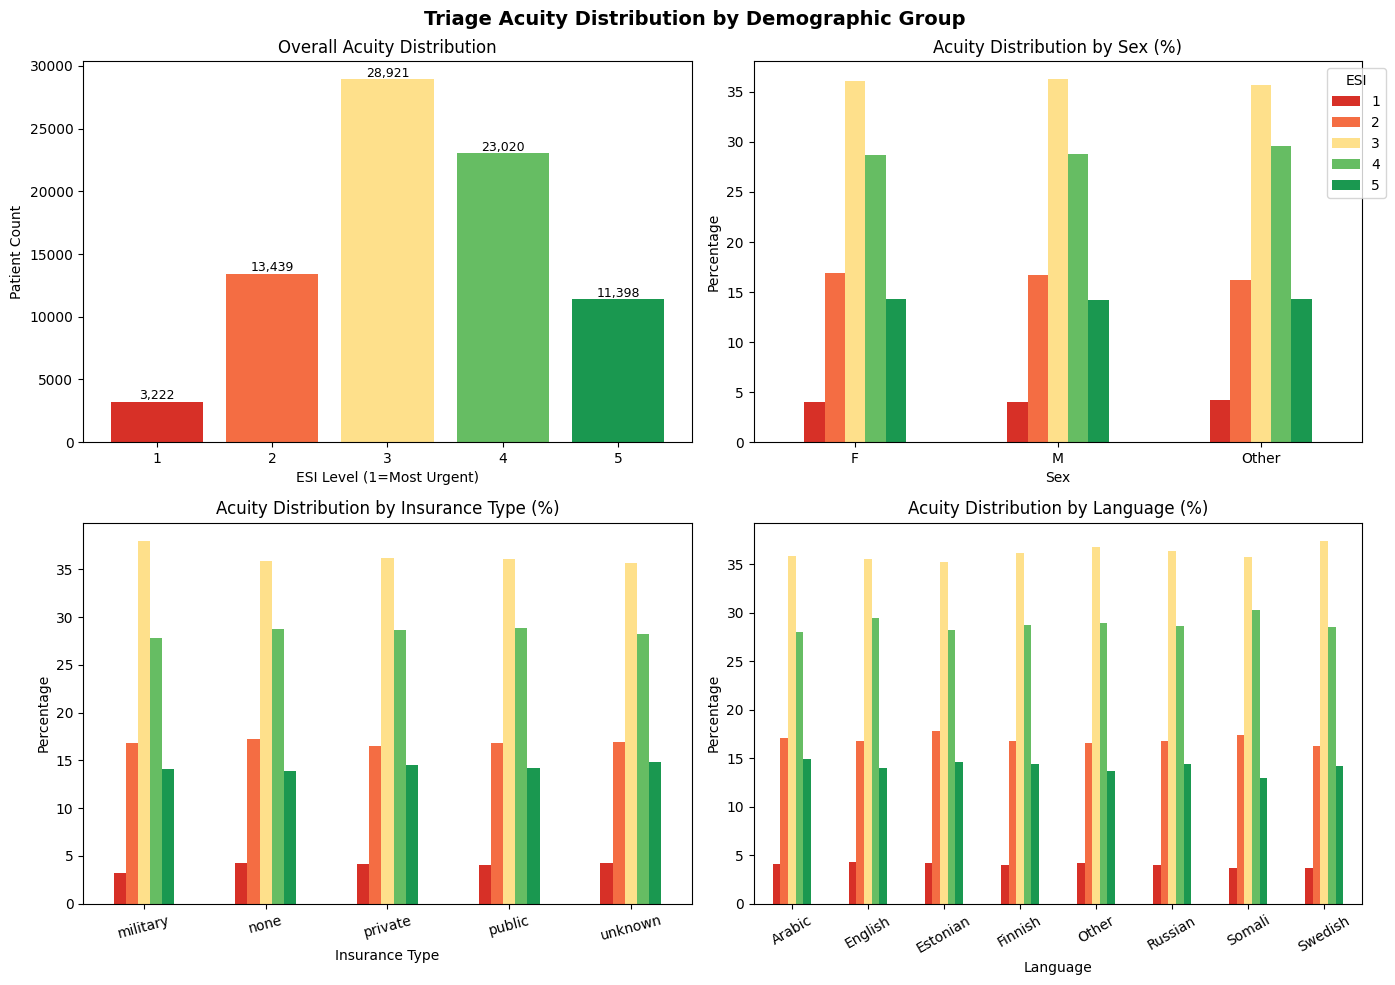

Chart saved to outputs folder.


In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Triage Acuity Distribution by Demographic Group', fontsize=14, fontweight='bold')

# 1. Overall acuity distribution
ax1 = axes[0, 0]
counts = train['triage_acuity'].value_counts().sort_index()
colors = ['#d73027', '#f46d43', '#fee08b', '#66bd63', '#1a9850']
bars = ax1.bar(counts.index, counts.values, color=colors)
ax1.set_title('Overall Acuity Distribution')
ax1.set_xlabel('ESI Level (1=Most Urgent)')
ax1.set_ylabel('Patient Count')
for bar, count in zip(bars, counts.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
             f'{count:,}', ha='center', fontsize=9)

# 2. Acuity by sex
ax2 = axes[0, 1]
sex_acuity = train.groupby(['sex', 'triage_acuity']).size().unstack()
sex_acuity_pct = sex_acuity.div(sex_acuity.sum(axis=1), axis=0) * 100
sex_acuity_pct.plot(kind='bar', ax=ax2, color=colors, legend=True)
ax2.set_title('Acuity Distribution by Sex (%)')
ax2.set_xlabel('Sex')
ax2.set_ylabel('Percentage')
ax2.legend(title='ESI', bbox_to_anchor=(1.05, 1))
ax2.tick_params(axis='x', rotation=0)

# 3. Acuity by insurance type
ax3 = axes[1, 0]
ins_acuity = train.groupby(['insurance_type', 'triage_acuity']).size().unstack()
ins_acuity_pct = ins_acuity.div(ins_acuity.sum(axis=1), axis=0) * 100
ins_acuity_pct.plot(kind='bar', ax=ax3, color=colors, legend=False)
ax3.set_title('Acuity Distribution by Insurance Type (%)')
ax3.set_xlabel('Insurance Type')
ax3.set_ylabel('Percentage')
ax3.tick_params(axis='x', rotation=15)

# 4. Acuity by language group
ax4 = axes[1, 1]
# Group smaller languages for clarity
language_map = {
    'Finnish': 'Finnish',
    'Swedish': 'Swedish',
    'English': 'English',
    'Russian': 'Russian',
    'Estonian': 'Estonian',
    'Arabic': 'Arabic',
    'Somali': 'Somali',
    'Other': 'Other'
}
train['language_group'] = train['language'].map(language_map)
lang_acuity = train.groupby(['language_group', 'triage_acuity']).size().unstack()
lang_acuity_pct = lang_acuity.div(lang_acuity.sum(axis=1), axis=0) * 100
lang_acuity_pct.plot(kind='bar', ax=ax4, color=colors, legend=False)
ax4.set_title('Acuity Distribution by Language (%)')
ax4.set_xlabel('Language')
ax4.set_ylabel('Percentage')
ax4.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('../outputs/01_acuity_by_demographics.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved to outputs folder.")

### Findings
Acuity distributions appear broadly similar across demographic groups at first glance. 
However, raw acuity assignment alone does not reveal bias — a patient can be assigned 
ESI 3 when their clinical signs warrant ESI 2. 

The true bias signal emerges when we compare **assigned acuity** against 
**model-predicted acuity based on clinical signs alone**. That analysis is 
conducted in Notebook 3.

## 7. Clinical Validity Check

Before modeling, we verify that the dataset reflects real clinical relationships. 
A clinically valid dataset should show clear vital sign deterioration as ESI level 
increases in urgency (i.e., ESI 1 patients should have the most abnormal vitals, 
ESI 5 the most normal).

This check is critical — if the data does not reflect real clinical patterns, 
any model trained on it would be clinically meaningless.

In [7]:
print("=== VITALS SUMMARY BY ACUITY LEVEL ===")
vitals = ['systolic_bp', 'heart_rate', 'respiratory_rate', 
          'spo2', 'gcs_total', 'news2_score', 'temperature_c']

summary = train.groupby('triage_acuity')[vitals].mean().round(2)
print(summary.to_string())

print("\n=== MISSING VITALS BY ACUITY LEVEL ===")
bp_missing = train.groupby('triage_acuity')['systolic_bp'].apply(
    lambda x: x.isnull().sum() / len(x) * 100
).round(1)
print("Systolic BP missing rate by ESI level:")
print(bp_missing)

=== VITALS SUMMARY BY ACUITY LEVEL ===
               systolic_bp  heart_rate  respiratory_rate   spo2  gcs_total  news2_score  temperature_c
triage_acuity                                                                                         
1                    82.50      119.29             27.95  85.86       6.49        13.64          38.91
2                   100.45      108.71             22.97  91.88      11.99        10.07          38.50
3                   126.19       93.02             17.99  95.87      15.00         2.61          37.70
4                   132.15       84.09             16.00  97.82      15.00         0.67          37.20
5                   128.06       76.99             15.03  98.92      15.00         0.35          36.91

=== MISSING VITALS BY ACUITY LEVEL ===
Systolic BP missing rate by ESI level:
triage_acuity
1     0.0
2     0.0
3     0.0
4    12.1
5    11.8
Name: systolic_bp, dtype: float64


### Findings

The dataset passes the clinical validity check with exceptional clarity:

| Vital Sign | ESI 1 (Critical) | ESI 5 (Non-urgent) | Clinical Interpretation |
|---|---|---|---|
| Systolic BP | 82.5 mmHg | 128.1 mmHg | ESI 1 = shock-level hypotension |
| Heart Rate | 119.3 bpm | 77.0 bpm | ESI 1 = tachycardia |
| SpO2 | 85.9% | 98.9% | ESI 1 = critical hypoxia |
| GCS | 6.5 | 15.0 | ESI 1 = severely altered consciousness |
| NEWS2 | 13.6 | 0.35 | ESI 1 = extreme early warning score |
| Temperature | 38.9°C | 36.9°C | ESI 1 = fever/sepsis pattern |

Every vital sign degrades monotonically from ESI 5 → ESI 1. This is exactly what 
a clinician would expect. The dataset is clinically sound and a model trained on 
it will learn genuine clinical relationships, not statistical artifacts.

**Missingness pattern:** Blood pressure is missing in 12.1% of ESI 4 and 11.8% 
of ESI 5 patients, but 0% of ESI 1 and ESI 2 patients — confirming that 
missingness is clinically informative, not random.

## 8. EDA Summary

We consolidate the key findings from our exploratory analysis before proceeding 
to modeling. This summary informs our modeling strategy and bias audit design.

In [8]:
print("=== EDA SUMMARY ===")
print(f"Training patients:        {len(train):,}")
print(f"Features available:       {train.shape[1] - 1}")
print(f"Target classes:           ESI 1-5")
print(f"Class imbalance:          ESI 1 = 4.0%, ESI 3 = 36.2%")
print(f"Missing BP rows:          4,146 (5.2%) — missing in ESI 4-5 only")
print(f"Pain score not recorded:  11,156 (13.9%) — encoded as -1")
print(f"")
print(f"Bias dimensions identified:")
print(f"  - Language: 8 groups including Arabic, Somali (linguistic minorities)")
print(f"  - Insurance: uninsured (none) = 6,320 patients")
print(f"  - Sex: includes Other category (1,926 patients)")
print(f"  - Age group: pediatric (6,595) and elderly (21,653)")
print(f"")
print(f"Key finding: Vitals degrade cleanly ESI 1→5.")
print(f"Model has strong signal. Ready for Phase 2.")

=== EDA SUMMARY ===
Training patients:        80,000
Features available:       40
Target classes:           ESI 1-5
Class imbalance:          ESI 1 = 4.0%, ESI 3 = 36.2%
Missing BP rows:          4,146 (5.2%) — missing in ESI 4-5 only
Pain score not recorded:  11,156 (13.9%) — encoded as -1

Bias dimensions identified:
  - Language: 8 groups including Arabic, Somali (linguistic minorities)
  - Insurance: uninsured (none) = 6,320 patients
  - Sex: includes Other category (1,926 patients)
  - Age group: pediatric (6,595) and elderly (21,653)

Key finding: Vitals degrade cleanly ESI 1→5.
Model has strong signal. Ready for Phase 2.


### Conclusion

The Triagegeist dataset is clinically realistic, demographically diverse, and 
well-suited for both predictive modeling and bias analysis. Key takeaways:

- **Strong signal:** Vital signs degrade cleanly across ESI levels — the model 
has clear clinical patterns to learn from
- **Realistic missingness:** Missing vitals are concentrated in low-acuity patients, 
reflecting real triage workflow
- **Rich bias dimensions:** Language, insurance, sex, and age group provide four 
distinct lenses for undertriage analysis
- **Finnish ED context:** The language distribution — including Russian, Arabic, 
and Somali speakers — makes this dataset uniquely relevant to Northern European 
emergency medicine research

**Next:** Notebook 2 builds the XGBoost triage acuity classifier.